# FIFA World Cup 2026 — Group Breakdown

Phase-1 validation report. Reads `data/worldcup.db` and renders every group as
**single-page landscape small multiples**: standings (P, W, D, L, GF, GA, GD,
Pts) plus the group's schedule table (date, teams, result/projection, weather as
icon + °F). Colour encodes time around *today*; finished winners are bold green,
projected favourites bold blue. Early gaps render as blanks, never errors.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

%matplotlib inline
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import report
from report_style import show_table_style
from config import DB_PATH

show_table_style()   # project-standard, high-contrast table theme
conn = sqlite3.connect(DB_PATH)
print("Database:", DB_PATH)

Database: /Users/marcalexander/projects/ai_orchestrator_claude/world_cup_soccer_2026/data/worldcup.db


## Data freshness — recent load runs

In [2]:
display(pd.read_sql(
    """SELECT run_id, run_type, started_at, cutoff_date,
              fixtures_upserted, status, notes
       FROM load_run ORDER BY run_id DESC LIMIT 5""", conn))
counts = {t: pd.read_sql(f"SELECT COUNT(*) n FROM {t}", conn)["n"][0]
          for t in ["team","venue","fixture","standing","prediction","weather"]}
print("row counts:", counts)
print("finished fixtures:", pd.read_sql("SELECT COUNT(*) n FROM fixture WHERE is_finished=1", conn)["n"][0])

,run_id,run_type,started_at,cutoff_date,fixtures_upserted,status,notes
0,17,players_both,2026-06-17T04:08:12.353410+00:00,None,0,ok,players=825 season_stats=825 fixture_stats=0
1,16,players_both,2026-06-17T00:57:29.088665+00:00,None,13,ok,players=825 season_stats=825 fixture_stats=671
2,15,players_season,2026-06-17T00:56:38.520637+00:00,None,0,ok,players=60 season_stats=60 fixture_stats=0
3,14,players_season,2026-06-17T00:55:24.036174+00:00,None,0,ok,players=60 season_stats=60 fixture_stats=0
4,13,players_both,2026-06-17T00:54:56.790834+00:00,None,3,ok,players=60 season_stats=60 fixture_stats=156


row counts: {'team': np.int64(48), 'venue': np.int64(16), 'fixture': np.int64(72), 'standing': np.int64(48), 'prediction': np.int64(31), 'weather': np.int64(72)}
finished fixtures: 16


## Group panels (single-page landscape)

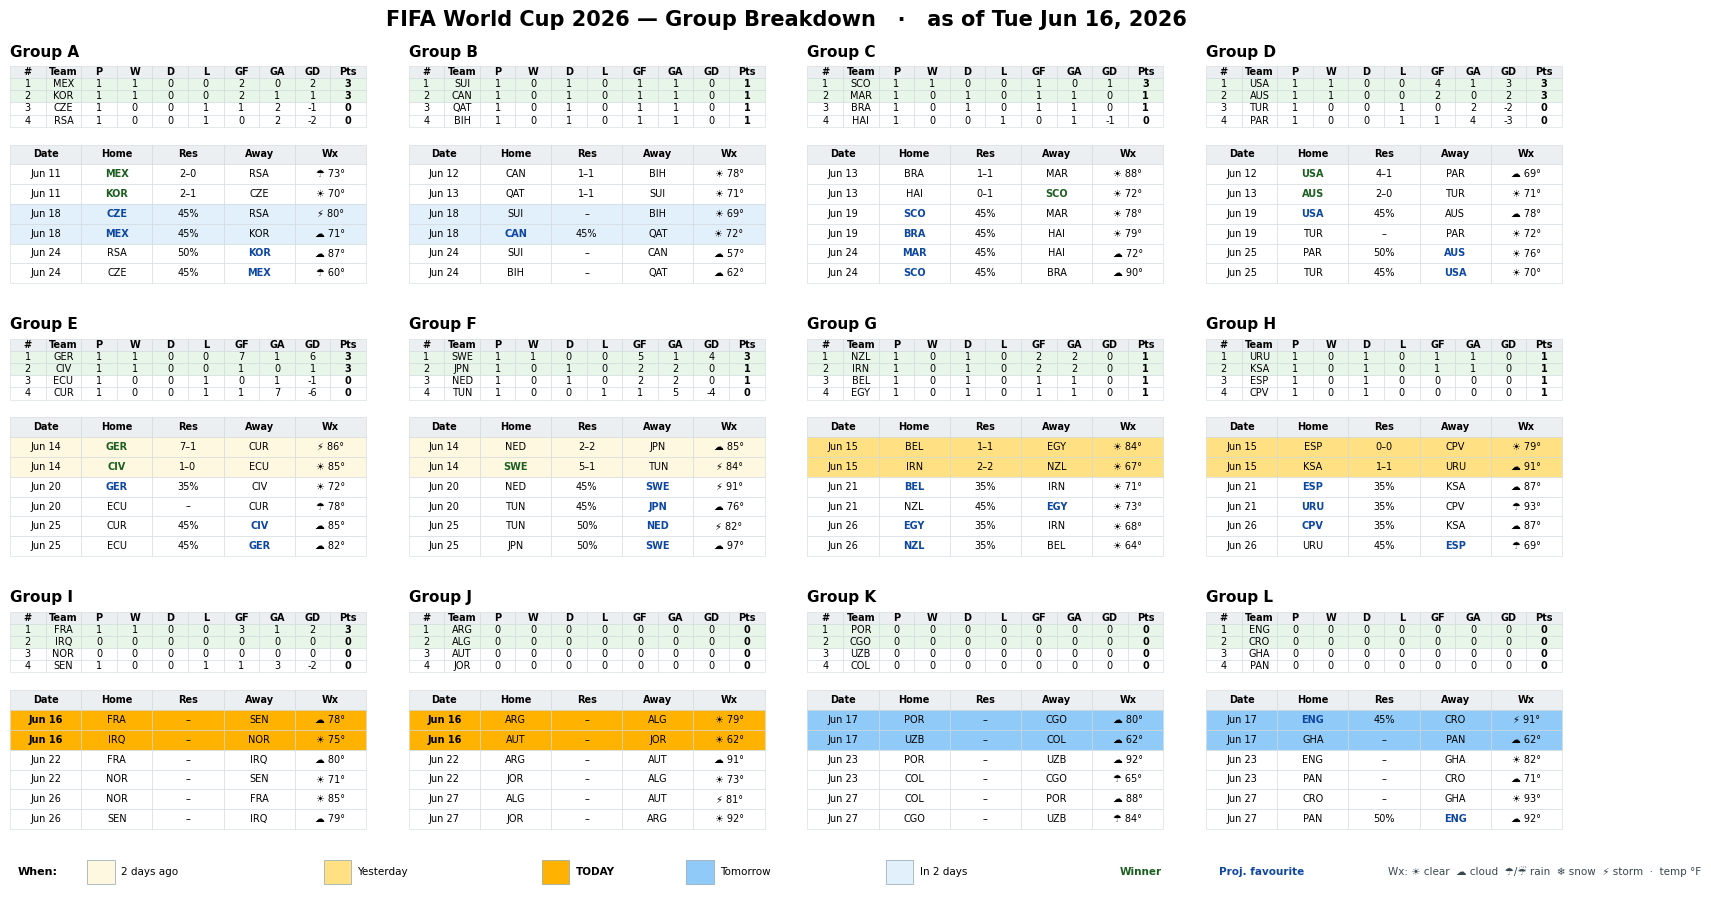

In [3]:
fig = report.build_group_breakdown_figure(conn)
plt.show()